
Training target: unemployment
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 718ms/step


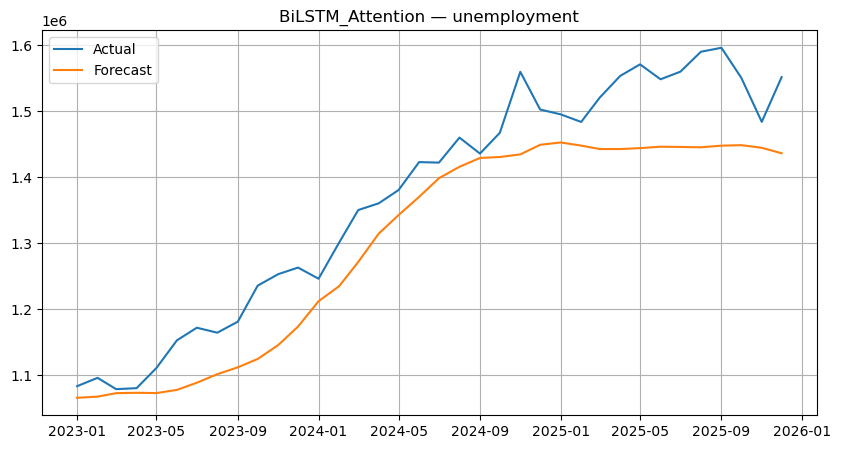


Training target: vacancies
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 620ms/step


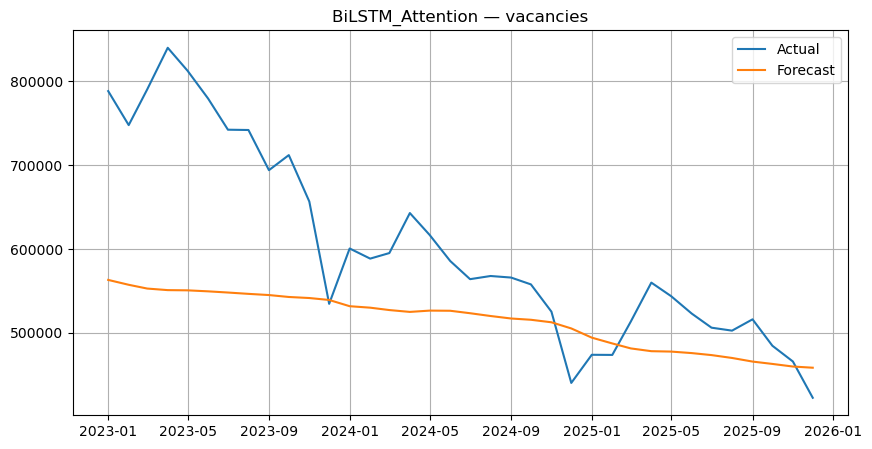


Training target: theta
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 525ms/step


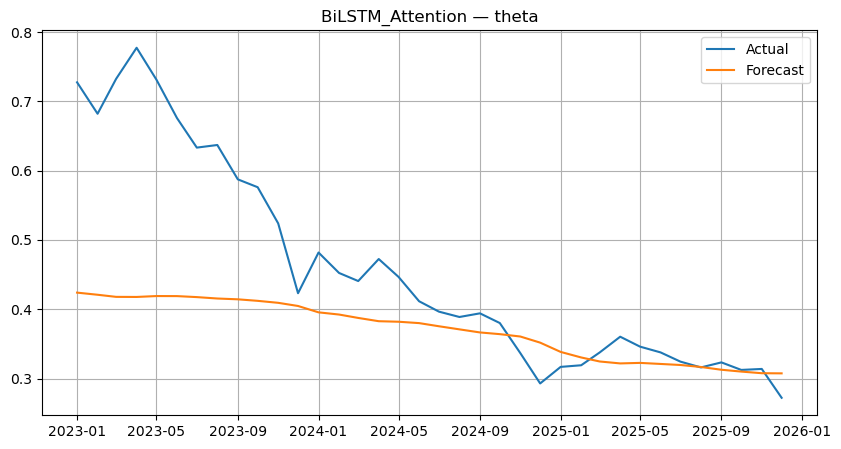


Metrics Summary
              model        target           RMSE           MAE       MAPE  \
0  BiLSTM_Attention  unemployment   79101.196633  68310.576041   4.875494   
1  BiLSTM_Attention     vacancies  124801.559884  95058.161437  14.097727   
2  BiLSTM_Attention         theta       0.144829      0.095831  16.467789   

       sMAPE      MASE  
0   5.034568  2.338488  
1  15.669423  3.021488  
2  19.206876  3.365100  

Forecast Contract Sample
                     model_name        target origin_date train_end_date  \
forecast_date                                                              
2023-01-01     BiLSTM_Attention  unemployment  2022-12-01     2022-12-01   
2023-02-01     BiLSTM_Attention  unemployment  2022-12-01     2022-12-01   
2023-03-01     BiLSTM_Attention  unemployment  2022-12-01     2022-12-01   
2023-04-01     BiLSTM_Attention  unemployment  2022-12-01     2022-12-01   
2023-05-01     BiLSTM_Attention  unemployment  2022-12-01     2022-12-01   

               

In [113]:
# ============================================================
# BILSTM-ATTENTION BASE MODEL — FROZEN IMPLEMENTATION
# Targets: unemployment, vacancies, theta
# ============================================================

import random
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt

# -------------------------------
# Reproducibility
# -------------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# -------------------------------
# Forecast evaluation contract
# -------------------------------
MODEL_NAME = "BiLSTM_Attention"
TRAIN_END = "2022-12-01"
TEST_START = "2023-01-01"
LOOKBACK = 12

TARGET_MAP = {
    "unemployment": "log_unemployment",
    "vacancies": "log_vacancies",
    "theta": "log_theta"
}

FEATURE_COLS = [
    "log_unemployment",
    "log_vacancies",
    "log_theta"
]

# ============================================================
# LOAD DATA
# ============================================================

from data_loader import load_dataset

df = load_dataset(verbose=False).copy()
df = df.sort_index()

# Create log transforms
df["log_unemployment"] = np.log1p(df["unemployment"])
df["log_vacancies"] = np.log1p(df["vacancies"])
df["log_theta"] = np.log1p(df["theta"])

# ============================================================
# SEQUENCE BUILDER
# ============================================================

def build_sequences(dataframe, target_col, lookback):

    X, y, dates = [], [], []

    values = dataframe.values
    cols = list(dataframe.columns)
    target_index = cols.index(target_col)

    for i in range(lookback, len(values)):
        X.append(values[i-lookback:i])
        y.append(values[i, target_index])
        dates.append(dataframe.index[i])

    return np.array(X), np.array(y), dates


# ============================================================
# ATTENTION LAYER
# ============================================================

from tensorflow.keras.layers import Layer
import tensorflow.keras.backend as K

class AttentionLayer(Layer):

    def build(self, input_shape):
        self.W = self.add_weight(
            shape=(input_shape[-1], 1),
            initializer="random_normal",
            trainable=True
        )
        self.b = self.add_weight(
            shape=(input_shape[1], 1),
            initializer="zeros",
            trainable=True
        )

    def call(self, x):
        e = K.tanh(K.dot(x, self.W) + self.b)
        a = K.softmax(e, axis=1)
        context = x * a
        context = K.sum(context, axis=1)
        return context


# ============================================================
# METRIC FUNCTIONS
# ============================================================

def smape(y_true, y_pred):
    return np.mean(
        2*np.abs(y_pred-y_true)/(np.abs(y_true)+np.abs(y_pred))
    )*100

def mase(y_true, y_pred):
    naive = np.mean(np.abs(np.diff(y_true)))
    mae = np.mean(np.abs(y_true-y_pred))
    return mae/naive


# ============================================================
# MAIN LOOP FOR ALL TARGETS
# ============================================================

all_metrics = []
all_forecasts = []

for TARGET_NAME, TARGET_COL in TARGET_MAP.items():

    print("\n===============================")
    print("Training target:", TARGET_NAME)
    print("===============================")

    # -------------------------------
    # Train/Test split
    # -------------------------------
    train_df = df.loc[:TRAIN_END, FEATURE_COLS]
    test_df = df.loc[TEST_START:, FEATURE_COLS]

    # -------------------------------
    # Scaling
    # -------------------------------
    scaler = StandardScaler()

    train_scaled = pd.DataFrame(
        scaler.fit_transform(train_df),
        index=train_df.index,
        columns=FEATURE_COLS
    )

    test_scaled = pd.DataFrame(
        scaler.transform(test_df),
        index=test_df.index,
        columns=FEATURE_COLS
    )

    # -------------------------------
    # Build sequences
    # -------------------------------
    X_train, y_train, train_dates = build_sequences(
        train_scaled, TARGET_COL, LOOKBACK
    )

    combined_test = pd.concat([train_scaled.tail(LOOKBACK), test_scaled])

    X_test, y_test, test_dates = build_sequences(
        combined_test, TARGET_COL, LOOKBACK
    )

    X_test = X_test[-len(test_scaled):]
    y_test = y_test[-len(test_scaled):]
    test_dates = test_dates[-len(test_scaled):]

    # -------------------------------
    # Train/Validation split
    # -------------------------------
    val_size = int(len(X_train)*0.15)

    X_train_core = X_train[:-val_size]
    y_train_core = y_train[:-val_size]

    X_val = X_train[-val_size:]
    y_val = y_train[-val_size:]

    # ============================================================
    # MODEL ARCHITECTURE
    # ============================================================

    from tensorflow.keras.models import Model
    from tensorflow.keras.layers import (
        Input, LSTM, Dense, Dropout, Bidirectional
    )

    inputs = Input(shape=(LOOKBACK, len(FEATURE_COLS)))

    x = Bidirectional(LSTM(64, return_sequences=True))(inputs)
    x = Dropout(0.2)(x)

    x = Bidirectional(LSTM(32, return_sequences=True))(x)
    x = Dropout(0.2)(x)

    x = AttentionLayer()(x)

    x = Dense(32, activation="relu")(x)
    x = Dropout(0.2)(x)

    output = Dense(1)(x)

    model = Model(inputs, output)

    model.compile(
        optimizer="adam",
        loss="mse",
        metrics=["mae"]
    )

    # ============================================================
    # TRAIN MODEL
    # ============================================================

    from tensorflow.keras.callbacks import EarlyStopping

    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True
    )

    model.fit(
        X_train_core,
        y_train_core,
        validation_data=(X_val, y_val),
        epochs=200,
        batch_size=16,
        callbacks=[early_stop],
        verbose=0
    )

    # ============================================================
    # PREDICTIONS
    # ============================================================

    preds_scaled = model.predict(X_test).flatten()

    pred_df = pd.DataFrame({
        "forecast_date": test_dates,
        "pred_scaled": preds_scaled,
        "actual_scaled": y_test
    }).set_index("forecast_date")

    # ============================================================
    # INVERSE SCALE
    # ============================================================

    target_index = FEATURE_COLS.index(TARGET_COL)

    def inverse_scale(values):
        dummy = np.zeros((len(values), len(FEATURE_COLS)))
        dummy[:,target_index] = values
        inv = scaler.inverse_transform(dummy)
        return inv[:,target_index]

    pred_log = inverse_scale(pred_df["pred_scaled"])
    actual_log = inverse_scale(pred_df["actual_scaled"])

    pred_level = np.expm1(pred_log)
    actual_level = np.expm1(actual_log)

    pred_df["predicted"] = pred_level
    pred_df["actual"] = actual_level

    # ============================================================
    # METRICS
    # ============================================================

    y_true = pred_df["actual"].values
    y_pred = pred_df["predicted"].values

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true-y_pred)/y_true))*100

    smape_val = smape(y_true, y_pred)
    mase_val = mase(y_true, y_pred)

    metrics = {
        "model": MODEL_NAME,
        "target": TARGET_NAME,
        "RMSE": rmse,
        "MAE": mae,
        "MAPE": mape,
        "sMAPE": smape_val,
        "MASE": mase_val
    }

    all_metrics.append(metrics)

    # ============================================================
    # EXPORT FORECAST CONTRACT
    # ============================================================

    pred_df["model_name"] = MODEL_NAME
    pred_df["target"] = TARGET_NAME
    pred_df["origin_date"] = TRAIN_END
    pred_df["train_end_date"] = TRAIN_END
    pred_df["forecast_horizon"] = np.arange(1, len(pred_df)+1)

    export_cols = [
        "model_name",
        "target",
        "origin_date",
        "train_end_date",
        "forecast_horizon",
        "predicted",
        "actual"
    ]

    all_forecasts.append(pred_df[export_cols])

    # ============================================================
    # VISUALIZATION
    # ============================================================

    plt.figure(figsize=(10,5))

    plt.plot(pred_df.index, pred_df["actual"], label="Actual")
    plt.plot(pred_df.index, pred_df["predicted"], label="Forecast")

    plt.title(f"{MODEL_NAME} — {TARGET_NAME}")
    plt.legend()
    plt.grid()

    plt.show()


# ============================================================
# FINAL TABLES
# ============================================================

metrics_df = pd.DataFrame(all_metrics)
forecast_df = pd.concat(all_forecasts)

print("\nMetrics Summary")
print(metrics_df)

print("\nForecast Contract Sample")
print(forecast_df.head())

In [114]:
# =============================================================================
# EXPORT BILSTM TEST PREDICTIONS FOR FINAL COMPARISON
# =============================================================================

from pathlib import Path
import pandas as pd

EXPORT_DIR = Path("exports/test_predictions")
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

# Use the arrays already produced by the model
pred = pd.DataFrame({
    "month": test_dates,     # test period dates used during prediction
    "actual": y_true,
    "prediction": y_pred
})

pred["month"] = pd.to_datetime(pred["month"])
pred = pred.sort_values("month").reset_index(drop=True)

# If the notebook predicted multiple targets, loop through them
targets = ["unemployment", "vacancies", "theta"]

for target in targets:

    temp = pred.copy()

    file_path = EXPORT_DIR / f"bilstm_{target}.csv"

    temp.to_csv(file_path, index=False)

    print("Saved →", file_path, "| shape:", temp.shape)

Saved → exports\test_predictions\bilstm_unemployment.csv | shape: (36, 3)
Saved → exports\test_predictions\bilstm_vacancies.csv | shape: (36, 3)
Saved → exports\test_predictions\bilstm_theta.csv | shape: (36, 3)
